# 0. Project Overview

## Prediksi Permeabilitas Molekul terhadap Membran Lipid Bilayer Menggunakan Machine Learning Berbasis Deskriptor Fisikokimia

Notebook ini digunakan sebagai file utama untuk demonstrasi program proyek. Proyek ini bertujuan untuk membangun pipeline machine learning yang dapat memprediksi permeabilitas molekul terhadap membran lipid bilayer berdasarkan deskriptor fisikokimia.

Input utama yang digunakan adalah struktur molekul dalam format SMILES, sedangkan target prediksi berupa kelas permeabilitas:

- `0` = low/moderate permeability
- `1` = high permeability

Pipeline proyek terdiri dari:

1. Load dataset
2. Dataset summary
3. Feature extraction
4. Descriptor EDA
5. Model training
6. Model evaluation
7. Model interpretation
8. New SMILES prediction
9. Conclusion

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_TABLES_DIR = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

RAW_DATA_PATH = DATA_RAW_DIR / "pampa_ncats_raw.csv"
DATASET_SUMMARY_PATH = RESULTS_TABLES_DIR / "dataset_summary.csv"
LABEL_DISTRIBUTION_PATH = RESULTS_FIGURES_DIR / "label_distribution.png"

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)
print("File exists:", RAW_DATA_PATH.exists())

Project root: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml
Raw data path: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\data\raw\pampa_ncats_raw.csv
File exists: True


# 1. Load Dataset

Dataset yang digunakan adalah PAMPA_NCATS, yaitu dataset permeabilitas molekul berbasis SMILES. Dataset ini digunakan sebagai data klasifikasi biner untuk membedakan molekul dengan permeabilitas rendah/sedang dan tinggi.

Pada tahap ini, dataset dibaca dari file lokal:

`data/raw/pampa_ncats_raw.csv`

File ini sudah distandarkan agar memiliki kolom utama:

- `Drug_ID`
- `SMILES`
- `Y`

In [2]:
raw_df = pd.read_csv(RAW_DATA_PATH)

print("Dataset berhasil dimuat.")
print("Shape:", raw_df.shape)

raw_df.head()

Dataset berhasil dimuat.
Shape: (2034, 3)


,Drug_ID,SMILES,Y
0,mol_0,CCCCOC1=CC=C(C=C1)CC(=O)NO,1
1,mol_1,COC1=C(C=C(C=C1)CCN2C(=CC(=O)NC2=S)N)OC,0
2,mol_2,COC1=C(C=C(C=C1)Cl)C(=O)NC2=CC=C(C=C2)NC(=O)C3...,1
3,mol_3,CC(C)(C)N1C2=NC=NC(=C2C(=N1)C3=CC=C(C=C3)Cl)N,1
4,mol_4,CN1C2=CC=CC=C2C(=O)C3=C1N=C(N(C3=O)C4=CC=CC=C4...,1


# 2. Dataset Summary

Bagian ini menampilkan ringkasan dataset, meliputi jumlah data, jumlah kolom, jumlah SMILES unik, missing value, serta distribusi label target.

Pemeriksaan distribusi label penting karena dataset klasifikasi dapat memiliki ketidakseimbangan kelas. Jika kelas target tidak seimbang, evaluasi model tidak cukup hanya menggunakan accuracy, tetapi juga perlu precision, recall, F1-score, ROC-AUC, dan confusion matrix.

In [3]:
dataset_summary = pd.read_csv(DATASET_SUMMARY_PATH)
dataset_summary

,metric,value
0,dataset_name,PAMPA_NCATS
1,n_rows,2034
2,n_columns,3
3,n_unique_smiles,2034
4,n_duplicate_smiles,0
5,missing_drug_id,0
6,missing_smiles,0
7,missing_target,0
8,class_0_count_low_moderate,295
9,class_1_count_high,1739


In [4]:
label_counts = raw_df["Y"].value_counts().sort_index()
label_percentages = raw_df["Y"].value_counts(normalize=True).sort_index() * 100

label_summary = pd.DataFrame({
    "label": label_counts.index,
    "description": ["Low/Moderate Permeability", "High Permeability"],
    "count": label_counts.values,
    "percentage": label_percentages.round(2).values
})

label_summary

,label,description,count,percentage
0,0,Low/Moderate Permeability,295,14.5
1,1,High Permeability,1739,85.5


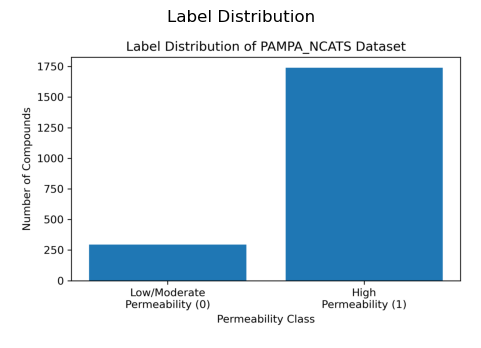

In [5]:
img = plt.imread(LABEL_DISTRIBUTION_PATH)

plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Label Distribution")
plt.show()

# 3. Feature Extraction

Bagian ini melakukan validasi SMILES dan ekstraksi deskriptor molekuler menggunakan RDKit.

Fitur yang digunakan:

- MolWt
- LogP
- TPSA
- HBD
- HBA
- RotatableBonds
- HeavyAtomCount
- RingCount
- FormalCharge

In [ ]:
# Jalankan script feature engineering
%run ../src/02_feature_engineering.py

In [6]:
features_path = DATA_PROCESSED_DIR / "pampa_features.csv"

if features_path.exists():
    features_df = pd.read_csv(features_path)
    display(features_df.head())
    print("Shape:", features_df.shape)
else:
    print("File pampa_features.csv belum ditemukan.")

NameError: name 'DATA_PROCESSED_DIR' is not defined

# 4. Descriptor EDA

Bagian ini menampilkan ringkasan statistik dan distribusi fitur molekuler.

In [ ]:
descriptor_summary_path = RESULTS_TABLES_DIR / "descriptor_summary.csv"

if descriptor_summary_path.exists():
    descriptor_summary = pd.read_csv(descriptor_summary_path)
    display(descriptor_summary)
else:
    print("File descriptor_summary.csv belum tersedia.")

In [ ]:
descriptor_distribution_path = RESULTS_FIGURES_DIR / "descriptor_distribution.png"

if descriptor_distribution_path.exists():
    img = plt.imread(descriptor_distribution_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Descriptor Distribution")
    plt.show()
else:
    print("Gambar descriptor_distribution.png belum tersedia.")

# 5. Model Training

Bagian ini melatih beberapa model klasifikasi:

- Logistic Regression
- Random Forest Classifier
- Support Vector Machine
- XGBoost Classifier / Gradient Boosting Classifier

In [ ]:
# Jalankan script modeling
%run ../src/03_modeling.py

# 6. Model Evaluation

Bagian ini mengevaluasi model menggunakan:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- ROC Curve

Confusion Matrix dan ROC Curve termasuk bagian evaluasi model, bukan bagian interpretasi biologis.

In [ ]:
model_comparison_path = RESULTS_TABLES_DIR / "model_comparison.csv"

if model_comparison_path.exists():
    model_comparison = pd.read_csv(model_comparison_path)
    display(model_comparison)
else:
    print("File model_comparison.csv belum tersedia.")

In [ ]:
model_comparison_fig_path = RESULTS_FIGURES_DIR / "model_comparison.png"

if model_comparison_fig_path.exists():
    img = plt.imread(model_comparison_fig_path)
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Model Comparison")
    plt.show()
else:
    print("Gambar model_comparison.png belum tersedia.")

In [ ]:
confusion_matrix_path = RESULTS_FIGURES_DIR / "confusion_matrix_best_model.png"

if confusion_matrix_path.exists():
    img = plt.imread(confusion_matrix_path)
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix - Best Model")
    plt.show()
else:
    print("Gambar confusion_matrix_best_model.png belum tersedia.")

In [ ]:
roc_curve_path = RESULTS_FIGURES_DIR / "roc_curve_best_model.png"

if roc_curve_path.exists():
    img = plt.imread(roc_curve_path)
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("ROC Curve - Best Model")
    plt.show()
else:
    print("Gambar roc_curve_best_model.png belum tersedia.")

# 7. Model Interpretation

Bagian ini menampilkan feature importance dari model terbaik dan menghubungkannya dengan konsep biologis lipid bilayer.

Contoh interpretasi:

- LogP berkaitan dengan lipofilisitas molekul.
- TPSA berkaitan dengan polaritas molekul.
- MolWt berkaitan dengan ukuran molekul.
- HBD dan HBA berkaitan dengan kemampuan membentuk ikatan hidrogen.
- FormalCharge berkaitan dengan muatan molekul.

In [ ]:
# Jalankan script interpretation and prediction
%run ../src/04_interpretation_and_prediction.py

In [ ]:
feature_importance_path = RESULTS_TABLES_DIR / "feature_importance.csv"

if feature_importance_path.exists():
    feature_importance = pd.read_csv(feature_importance_path)
    display(feature_importance)
else:
    print("File feature_importance.csv belum tersedia.")

In [ ]:
feature_importance_fig_path = RESULTS_FIGURES_DIR / "feature_importance.png"

if feature_importance_fig_path.exists():
    img = plt.imread(feature_importance_fig_path)
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Feature Importance")
    plt.show()
else:
    print("Gambar feature_importance.png belum tersedia.")

# 8. New SMILES Prediction

Bagian ini menunjukkan demo prediksi molekul baru berdasarkan input SMILES.

Program akan menghitung fitur molekul, memuat model terbaik, lalu menghasilkan prediksi kelas permeabilitas.

In [ ]:
demo_predictions_path = RESULTS_TABLES_DIR / "demo_predictions.csv"

if demo_predictions_path.exists():
    demo_predictions = pd.read_csv(demo_predictions_path)
    display(demo_predictions)
else:
    print("File demo_predictions.csv belum tersedia.")

# 9. Conclusion

Kesimpulan sementara:

- Pipeline machine learning berhasil disusun untuk memprediksi permeabilitas molekul terhadap membran lipid bilayer.
- Input utama berupa SMILES molekul yang diubah menjadi deskriptor fisikokimia.
- Model dievaluasi sebagai masalah klasifikasi biner.
- Feature importance digunakan untuk menghubungkan hasil model dengan konsep biologis permeabilitas membran.
- Demo prediksi SMILES baru digunakan untuk menunjukkan bahwa model dapat diterapkan pada input molekul baru.